Trains a Random Forest classifier on both dataset splits:
- Dataset A (imputed): NaNs filled with per-group median
- Dataset B (dropped): rows with NaN removed

Pipeline: StandardScaler -> RandomForestClassifier(class_weight='balanced').
CV: GroupKFold(k=5) grouped by subject ID to prevent leakage from ~6 recordings per subject.
Hyperparameter tuning: inner GridSearchCV scored by macro F1.
Sensitivity: 2 by 2 grid over feature subset (all 22 vs. jitter+shimmer 11) and outlier conditions

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
)

os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

PALETTE = {'SVM': '#7F77DD',
            'HGB': '#1D9E75', 
            'LR': '#BA7517', 
            'RF': '#B07FC8',
            'PD': '#E24B4A', 
            'Healthy': '#378ADD'}
COL_RF  = '#B07FC8'


In [2]:
# load data
train_a = pd.read_csv('../../data/train_a.csv')
test_a  = pd.read_csv('../../data/test_a.csv')
train_b = pd.read_csv('../../data/train_b.csv')
test_b  = pd.read_csv('../../data/test_b.csv')

feature_cols = [c for c in train_a.columns if c not in ('name', 'status')]

JITTER_SHIMMER = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
]

print(f'Features (all):           {len(feature_cols)}')
print(f'Features (jitter+shimmer): {len(JITTER_SHIMMER)}')
print(f'Dataset A — train: {len(train_a)}, test: {len(test_a)}')
print(f'Dataset B — train: {len(train_b)}, test: {len(test_b)}')

Features (all):           22
Features (jitter+shimmer): 11
Dataset A — train: 152, test: 43
Dataset B — train: 146, test: 41


Reproduces the three-flag outlier union from outlier_analysis.ipynb:
- IQR rule triggered in >= 3 features
- Z-score > 3 in any feature
- PCA Mahalanobis distance > 97.5th percentile (per-class)

In [3]:
def _fit_outlier_detector(train_df, feat_cols):
    """Fit IQR bounds, scaler, PCA(2), and Mahalanobis threshold on train_df."""
    iqr_bounds = {}
    for c in feat_cols:
        Q1, Q3 = train_df[c].quantile(0.25), train_df[c].quantile(0.75)
        iqr_bounds[c] = (Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1))

    scaler   = StandardScaler().fit(train_df[feat_cols])
    X_sc_tr  = scaler.transform(train_df[feat_cols])
    pca      = PCA(n_components=2).fit(X_sc_tr)
    X_pca_tr = pca.transform(X_sc_tr)

    mu      = X_pca_tr.mean(axis=0)
    cov_inv = np.linalg.pinv(np.cov(X_pca_tr.T))
    d       = X_pca_tr - mu
    thresh  = np.percentile(np.sqrt(np.einsum('ij,jk,ik->i', d, cov_inv, d)), 97.5)
    return iqr_bounds, scaler, pca, mu, cov_inv, thresh


def _apply_outlier_flags(df, feat_cols, iqr_bounds, scaler, pca, mu, cov_inv, thresh):
    """Apply fitted detector to df; returns set of outlier recording names."""
    iqr_count = np.zeros(len(df), dtype=int)
    for c, (lo, hi) in iqr_bounds.items():
        iqr_count += ((df[c].values < lo) | (df[c].values > hi)).astype(int)

    X_sc  = scaler.transform(df[feat_cols])
    X_pca = pca.transform(X_sc)
    d     = X_pca - mu
    mahal = np.sqrt(np.einsum('ij,jk,ik->i', d, cov_inv, d))
    mask  = (iqr_count >= 3) | (np.abs(X_sc) > 3).any(axis=1) | (mahal > thresh)
    return set(df['name'].values[mask])


# Dataset A: fit on train_a, apply to train_a and test_a
_det_a = _fit_outlier_detector(train_a, feature_cols)
train_a_outlier_names = _apply_outlier_flags(train_a, feature_cols, *_det_a)
test_a_outlier_names  = _apply_outlier_flags(test_a,  feature_cols, *_det_a)

# Dataset B: fit on train_b, apply to train_b and test_b
_det_b = _fit_outlier_detector(train_b, feature_cols)
train_b_outlier_names = _apply_outlier_flags(train_b, feature_cols, *_det_b)
test_b_outlier_names  = _apply_outlier_flags(test_b,  feature_cols, *_det_b)

print(f'Outliers A, train: {len(train_a_outlier_names)}, test: {len(test_a_outlier_names)}')
print(f'Outliers B, train: {len(train_b_outlier_names)}, test: {len(test_b_outlier_names)}')

# Filter train/test splits
train_a_clean = train_a[~train_a['name'].isin(train_a_outlier_names)].reset_index(drop=True)
test_a_clean  = test_a[~test_a['name'].isin(test_a_outlier_names)].reset_index(drop=True)
train_b_clean = train_b[~train_b['name'].isin(train_b_outlier_names)].reset_index(drop=True)
test_b_clean  = test_b[~test_b['name'].isin(test_b_outlier_names)].reset_index(drop=True)

print(f'Train A: {len(train_a)} -> {len(train_a_clean)} | Test A: {len(test_a)} -> {len(test_a_clean)}')
print(f'Train B: {len(train_b)} -> {len(train_b_clean)} | Test B: {len(test_b)} -> {len(test_b_clean)}')


Outliers A, train: 22, test: 7
Outliers B, train: 21, test: 7
Train A: 152 -> 130 | Test A: 43 -> 36
Train B: 146 -> 125 | Test B: 41 -> 34


In [4]:
# pipeline and hyperparameter grid
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(class_weight='balanced', random_state=42)),
])

param_grid = {
    'rf__n_estimators':     [100, 200],
    'rf__max_depth':        [None, 10, 20],
    'rf__min_samples_leaf': [1, 5],
}

print('Pipeline steps:', list(pipe.named_steps))
print('Param grid:',     param_grid)

Pipeline steps: ['scaler', 'rf']
Param grid: {'rf__n_estimators': [100, 200], 'rf__max_depth': [None, 10, 20], 'rf__min_samples_leaf': [1, 5]}


GroupKFold(k=5) groups recordings by subject so the same subject never appears
in both train and validation folds (prevents leakage from the ~6 recordings per subject)

- Outer loop (k=5): unbiased performance estimation
- Inner loop (k=5): GridSearchCV over n_estimators and max_depth and min_samples_leaf,
  -> scored by macro F1

Four configurations per dataset (A / B):
all 22 features, just jitter + shimmer, and both with and without outliers

In [5]:
def nested_cv(estimator, param_grid, X, y, groups, outer_k=5, inner_k=5):
    outer_cv = GroupKFold(n_splits=outer_k)
    inner_cv = GroupKFold(n_splits=inner_k)
    fold_acc, fold_ba, fold_f1, best_params_list = [], [], [], []

    for train_idx, val_idx in outer_cv.split(X, y, groups):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        g_tr        = groups[train_idx]

        gs = GridSearchCV(
            estimator, param_grid,
            cv=inner_cv, scoring='f1_macro', refit=True, n_jobs=1,
        )
        gs.fit(X_tr, y_tr, groups=g_tr)

        y_pred = gs.predict(X_val)
        fold_acc.append(accuracy_score(y_val, y_pred))
        fold_ba.append(balanced_accuracy_score(y_val, y_pred))
        fold_f1.append(f1_score(y_val, y_pred, average='macro'))
        best_params_list.append(gs.best_params_)

    return {
        'accuracy':          np.array(fold_acc),
        'balanced_accuracy': np.array(fold_ba),
        'f1_macro':          np.array(fold_f1),
        'best_params':       best_params_list,
    }


feature_sets = {
    'All features':   feature_cols,
    'Jitter+Shimmer': JITTER_SHIMMER,
}

outlier_configs = {
    'With outliers':    {'A': (train_a,       test_a),       'B': (train_b,       test_b)},
    'Without outliers': {'A': (train_a_clean, test_a_clean), 'B': (train_b_clean, test_b_clean)},
}

cv_results = {}
configs    = {}

for feat_label, cols in feature_sets.items():
    for outlier_label, splits in outlier_configs.items():
        for ds_label, (tr, te) in [('A (imputed)', splits['A']), ('B (dropped)', splits['B'])]:
            key = (feat_label, outlier_label, ds_label)
            print(f'{feat_label} | {outlier_label} | Dataset {ds_label} ...', flush=True)

            pipe_run = Pipeline([
                ('scaler', StandardScaler()),
                ('rf',     RandomForestClassifier(class_weight='balanced', random_state=42)),
            ])

            X      = tr[cols].values
            y      = tr['status'].values
            groups = tr['name'].str.rsplit('_', n=1).str[0].values

            res = nested_cv(pipe_run, param_grid, X, y, groups)
            cv_results[key] = res
            configs[key]    = {'train_df': tr, 'test_df': te, 'cols': cols}

            print(f'  balanced acc : {res["balanced_accuracy"].mean():.3f} ± {res["balanced_accuracy"].std():.3f}')
            print(f'  macro F1     : {res["f1_macro"].mean():.3f} ± {res["f1_macro"].std():.3f}')
            print()


All features | With outliers | Dataset A (imputed) ...
  balanced acc : 0.709 ± 0.203
  macro F1     : 0.581 ± 0.193

All features | With outliers | Dataset B (dropped) ...
  balanced acc : 0.591 ± 0.223
  macro F1     : 0.562 ± 0.238

All features | Without outliers | Dataset A (imputed) ...
  balanced acc : 0.592 ± 0.214
  macro F1     : 0.458 ± 0.133

All features | Without outliers | Dataset B (dropped) ...
  balanced acc : 0.669 ± 0.123
  macro F1     : 0.517 ± 0.160

Jitter+Shimmer | With outliers | Dataset A (imputed) ...
  balanced acc : 0.575 ± 0.200
  macro F1     : 0.439 ± 0.050

Jitter+Shimmer | With outliers | Dataset B (dropped) ...
  balanced acc : 0.550 ± 0.148
  macro F1     : 0.442 ± 0.056

Jitter+Shimmer | Without outliers | Dataset A (imputed) ...
  balanced acc : 0.554 ± 0.191
  macro F1     : 0.406 ± 0.054

Jitter+Shimmer | Without outliers | Dataset B (dropped) ...
  balanced acc : 0.624 ± 0.161
  macro F1     : 0.432 ± 0.060



In [6]:
# CV results
cv_rows = []
for (feat_label, outlier_label, ds_label), res in cv_results.items():
    cv_rows.append({
        'Feature set':  feat_label,
        'Outliers':     outlier_label,
        'Dataset':      ds_label,
        'Accuracy':     f'{res["accuracy"].mean():.3f} ± {res["accuracy"].std():.3f}',
        'Balanced Acc': f'{res["balanced_accuracy"].mean():.3f} ± {res["balanced_accuracy"].std():.3f}',
        'Macro F1':     f'{res["f1_macro"].mean():.3f} ± {res["f1_macro"].std():.3f}',
    })

display(pd.DataFrame(cv_rows))

,Feature set,Outliers,Dataset,Accuracy,Balanced Acc,Macro F1
0,All features,With outliers,A (imputed),0.802 ± 0.137,0.709 ± 0.203,0.581 ± 0.193
1,All features,With outliers,B (dropped),0.733 ± 0.150,0.591 ± 0.223,0.562 ± 0.238
2,All features,Without outliers,A (imputed),0.693 ± 0.166,0.592 ± 0.214,0.458 ± 0.133
3,All features,Without outliers,B (dropped),0.689 ± 0.116,0.669 ± 0.123,0.517 ± 0.160
4,Jitter+Shimmer,With outliers,A (imputed),0.703 ± 0.138,0.575 ± 0.200,0.439 ± 0.050
5,Jitter+Shimmer,With outliers,B (dropped),0.698 ± 0.084,0.550 ± 0.148,0.442 ± 0.056
6,Jitter+Shimmer,Without outliers,A (imputed),0.656 ± 0.148,0.554 ± 0.191,0.406 ± 0.054
7,Jitter+Shimmer,Without outliers,B (dropped),0.657 ± 0.144,0.624 ± 0.161,0.432 ± 0.060


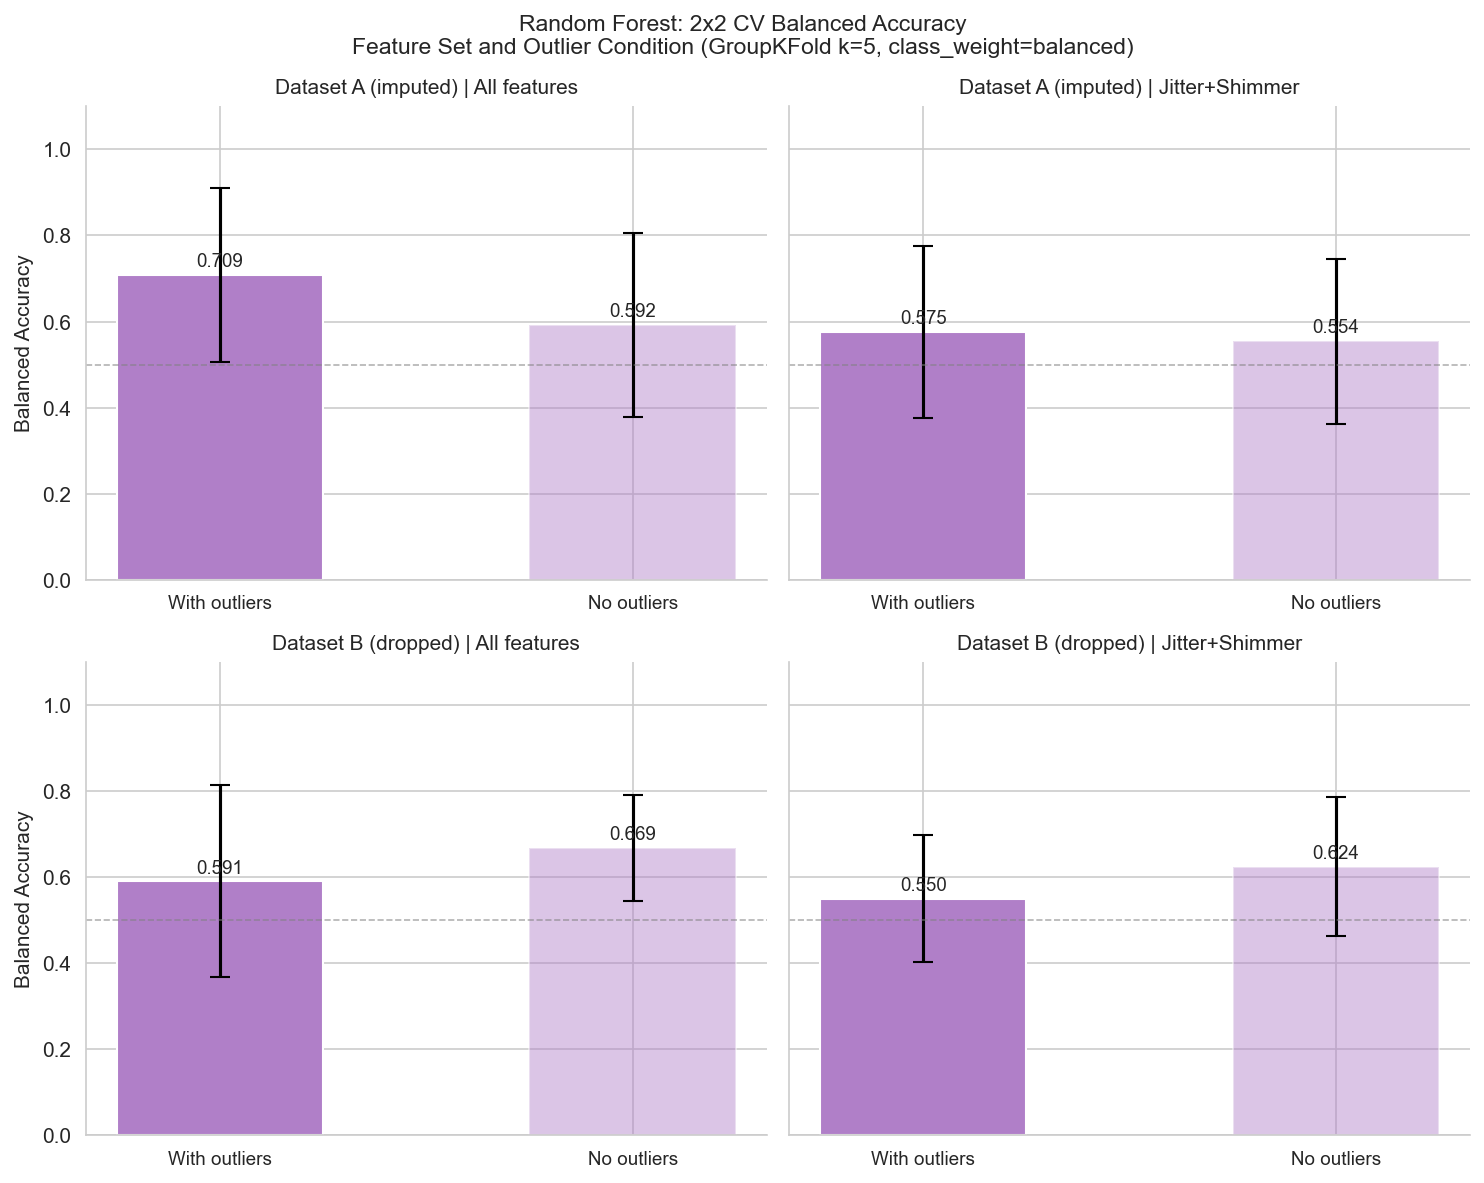

In [7]:
# 2x2 panel: rows = datasets, cols = feature sets, bars = with/without outliers
ds_labels_grid   = ['A (imputed)', 'B (dropped)']
feat_labels_grid = ['All features', 'Jitter+Shimmer']
out_labels       = ['With outliers', 'Without outliers']
bar_colors = [COL_RF, COL_RF]
opacities  = [1.0, 0.45]
x                = np.arange(len(out_labels))
width            = 0.5

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)

for row_i, ds_label in enumerate(ds_labels_grid):
    for col_i, feat_label in enumerate(feat_labels_grid):
        ax    = axes[row_i, col_i]
        means = [cv_results[(feat_label, ol, ds_label)]['balanced_accuracy'].mean()
                 for ol in out_labels]
        stds  = [cv_results[(feat_label, ol, ds_label)]['balanced_accuracy'].std()
                 for ol in out_labels]

        bars = ax.bar(x, means, width, yerr=stds, capsize=5,
                      color=bar_colors, alpha=0.85, edgecolor='white')

        for bar, alpha in zip(bars, opacities):
            bar.set_alpha(alpha)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9)

        ax.set_xticks(x)
        ax.set_xticklabels(['With outliers', 'No outliers'], fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_ylabel('Balanced Accuracy' if col_i == 0 else '')
        ax.set_title(f'Dataset {ds_label} | {feat_label}', fontsize=10)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle(
    'Random Forest: 2x2 CV Balanced Accuracy\n'
    'Feature Set and Outlier Condition (GroupKFold k=5, class_weight=balanced)',
    fontsize=11,
)
plt.tight_layout()
plt.savefig('outputs/rf_2x2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Final Evaluation on Held-Out Test Sets

-> for each configuration a new GridSearchCV is fitted on the full training set (inner 5-fold GroupKFold), then the best pipeline is evaluated on the held-out test set 

In [8]:
test_rows = []

for (feat_label, outlier_label, ds_label), cfg in configs.items():
    tr, te = cfg['train_df'], cfg['test_df']
    cols   = cfg['cols']

    pipe_final = Pipeline([
        ('scaler', StandardScaler()),
        ('rf',     RandomForestClassifier(class_weight='balanced', random_state=42)),
    ])

    X_train = tr[cols].values
    y_train = tr['status'].values
    g_train = tr['name'].str.rsplit('_', n=1).str[0].values
    X_test  = te[cols].values
    y_test  = te['status'].values

    gs = GridSearchCV(
        pipe_final, param_grid,
        cv=GroupKFold(n_splits=5), scoring='f1_macro', refit=True, n_jobs=1,
    )
    gs.fit(X_train, y_train, groups=g_train)
    y_pred = gs.predict(X_test)

    test_rows.append({
        'Feature set':  feat_label,
        'Outliers':     outlier_label,
        'Dataset':      ds_label,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 3),
        'Balanced Acc': round(balanced_accuracy_score(y_test, y_pred), 3),
        'Macro F1':     round(f1_score(y_test, y_pred, average='macro'), 3),
        'Best params':  gs.best_params_,
    })

display(pd.DataFrame(test_rows))


,Feature set,Outliers,Dataset,Accuracy,Balanced Acc,Macro F1,Best params
0,All features,With outliers,A (imputed),0.860,0.750,0.789,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
1,All features,With outliers,B (dropped),0.878,0.792,0.829,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
2,All features,Without outliers,A (imputed),0.889,0.800,0.839,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
3,All features,Without outliers,B (dropped),0.882,0.800,0.837,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
4,Jitter+Shimmer,With outliers,A (imputed),0.860,0.750,0.789,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
5,Jitter+Shimmer,With outliers,B (dropped),0.854,0.750,0.786,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
6,Jitter+Shimmer,Without outliers,A (imputed),0.889,0.800,0.839,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."
7,Jitter+Shimmer,Without outliers,B (dropped),0.882,0.800,0.837,"{'rf__max_depth': None, 'rf__min_samples_leaf'..."


Feature Importance

-> fit the best model (Dataset A, all 22 features, with outliers) on the full training set and extract mean-decrease-in-impurity importances from the fitted RandomForestClassifier

Best params (Dataset A, all features): {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}


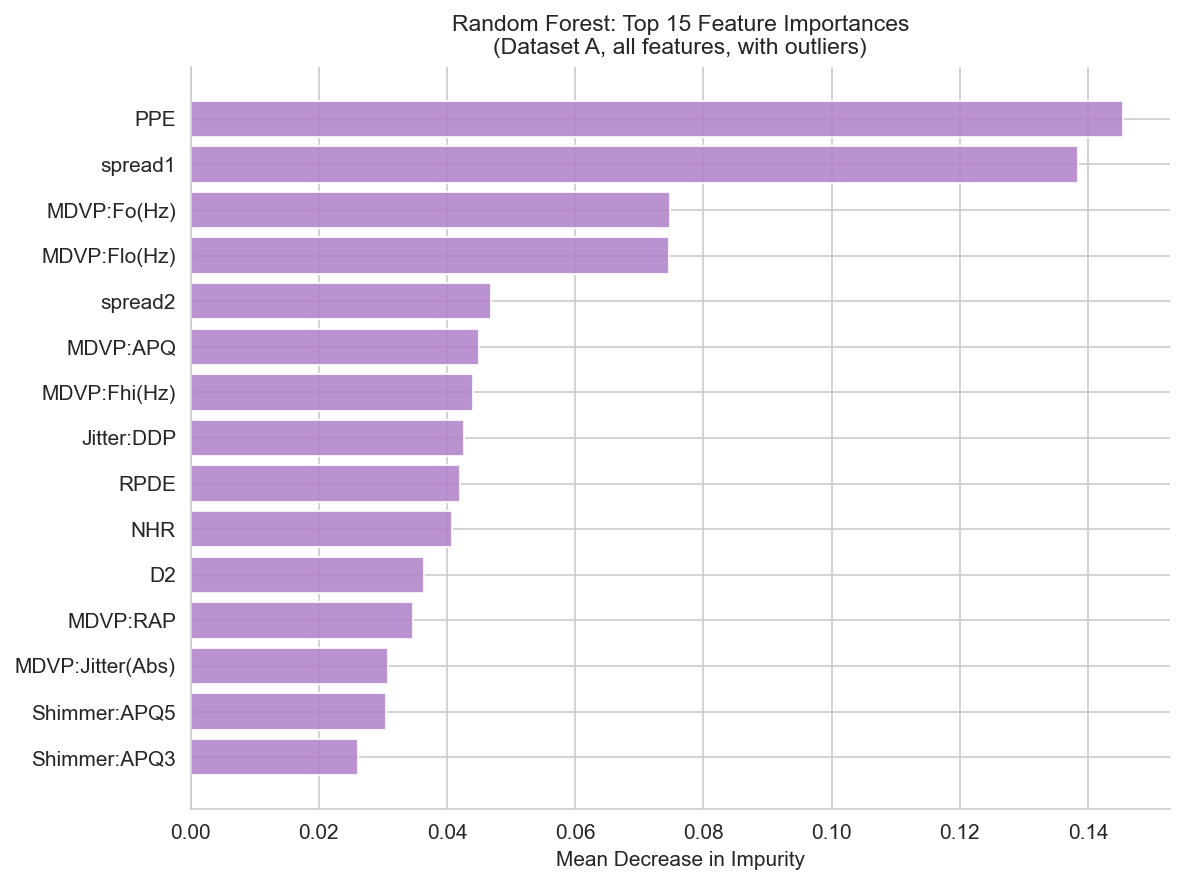

In [9]:
key_best  = ('All features', 'With outliers', 'A (imputed)')
cfg_best  = configs[key_best]
tr_best   = cfg_best['train_df']
cols_best = cfg_best['cols']

pipe_imp = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(class_weight='balanced', random_state=42)),
])

X_imp = tr_best[cols_best].values
y_imp = tr_best['status'].values
g_imp = tr_best['name'].str.rsplit('_', n=1).str[0].values

gs_imp = GridSearchCV(
    pipe_imp, param_grid,
    cv=GroupKFold(n_splits=5), scoring='f1_macro', refit=True, n_jobs=1,
)
gs_imp.fit(X_imp, y_imp, groups=g_imp)
print('Best params (Dataset A, all features):', gs_imp.best_params_)

importances = gs_imp.best_estimator_.named_steps['rf'].feature_importances_
feat_imp_df = (
    pd.DataFrame({'feature': cols_best, 'importance': importances})
    .sort_values('importance', ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
        color=COL_RF, alpha=0.85, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title(
    'Random Forest: Top 15 Feature Importances\n'
    '(Dataset A, all features, with outliers)',
    fontsize=11,
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
